<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Recommendation Engine

## Business Objective

Modern e-commerce businesses use recommendation systems to personalize the shopping experience and increase customer engagement. Rather than showing the same products to every customer, intelligent recommendation engines analyze historical purchase behaviour to suggest products that are most relevant to each customer.

In this notebook, an AI-powered recommendation system is developed using Collaborative Filtering with Cosine Similarity. The engine identifies customers with similar purchasing behaviour and recommends products purchased by similar customers but not yet purchased by the target customer.

To further improve recommendation quality, a Hybrid Recommendation Strategy is implemented by combining:

- Popularity-based recommendations
- Customer similarity (Collaborative Filtering)
- Business rule-based recommendations

This approach enables the business to:

- Increase Average Order Value
- Improve Customer Satisfaction
- Enhance Cross-selling Opportunities
- Increase Customer Retention
- Deliver Personalized Shopping Experiences

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import joblib

plt.style.use("default")
sns.set_style("whitegrid")

#  Loading Transaction Dataset

The original Online Retail II transaction dataset is loaded for building the recommendation engine. Unlike previous notebooks that used customer-level aggregated features, this notebook operates on transaction-level purchase history because recommendation systems require detailed purchase interactions between customers and products.

In [2]:
df = pd.read_csv(
    "../data/raw/online_retail_II.csv"
)

#  Basic Data Cleaning

Minimal preprocessing is performed to prepare the transaction dataset for recommendation modelling.

The following steps are applied:

- Remove transactions without Customer IDs
- Remove cancelled invoices
- Remove negative quantities
- Remove negative prices
- Remove duplicate transactions

In [3]:
df = df.dropna(subset=['Customer ID'])

In [4]:
df = df[
    ~df["Invoice"].astype(str).str.startswith("C")
]

In [5]:
df = df[df['Quantity'] > 0]

In [6]:
df = df[df['Price'] > 0]

In [7]:
df = df.drop_duplicates()

In [8]:
df.reset_index(drop=True, inplace=True)

In [9]:
print(df.shape)

df.head()

(779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


#  Product Analytics

Before building recommendations, exploratory analysis is performed to understand customer purchasing behaviour and product popularity.

The analysis focuses on:

- Most purchased products
- Highest revenue products
- Country-wise transactions
- Product purchase frequency

These insights help explain the recommendation engine's behaviour.

# ️ Building the Customer–Product Matrix

A recommendation engine requires understanding which products each customer has purchased.

A Customer–Product Matrix is created where:

- Each row represents a customer.
- Each column represents a product.
- Cell values represent the quantity purchased.

This matrix forms the foundation of collaborative filtering and customer similarity analysis.

In [10]:
customer_product_matrix = df.pivot_table(
    index="Customer ID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

customer_product_matrix.head()

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
print(customer_product_matrix.shape)

(5878, 5283)


#  Matrix Sparsity Analysis

Retail transaction datasets are highly sparse because each customer purchases only a small subset of all available products.

Understanding sparsity helps explain why similarity-based recommendation methods are effective.

In [12]:
sparsity = (
    customer_product_matrix == 0
).sum().sum() / np.prod(customer_product_matrix.shape)

print(f"Sparsity: {sparsity:.2%}")

Sparsity: 98.41%


#  Computing Customer Similarity

Cosine Similarity measures how similar two customers are based on their purchase history.

Customers with similar purchasing behaviour are likely to be interested in similar products.

The similarity matrix is later used to generate personalized product recommendations.

In [13]:
customer_similarity = cosine_similarity(
    customer_product_matrix
)

In [14]:
customer_similarity_df = pd.DataFrame(
    customer_similarity,
    index=customer_product_matrix.index,
    columns=customer_product_matrix.index
)

customer_similarity_df.head()

Customer ID,12346.0,12347.0,12348.0,12349.0,12350.0,12351.0,12352.0,12353.0,12354.0,12355.0,...,18278.0,18279.0,18280.0,18281.0,18282.0,18283.0,18284.0,18285.0,18286.0,18287.0
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,1.000000,0.000000,0.000000,0.000002,0.000000,0.000000,2.554410e-07,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,8.762815e-07,0.000000
12347.0,0.000000,1.000000,0.162033,0.012087,0.013398,0.042812,2.250879e-02,0.021666,0.021202,0.408637,...,0.014974,0.0,0.017170,0.031768,0.012001,0.097815,0.029073,0.0,3.445478e-02,0.069793
12348.0,0.000000,0.162033,1.000000,0.000246,0.000316,0.000000,1.066435e-03,0.000000,0.012006,0.213272,...,0.000000,0.0,0.000000,0.000000,0.000000,0.159949,0.000000,0.0,0.000000e+00,0.063602
12349.0,0.000002,0.012087,0.000246,1.000000,0.029190,0.012112,1.198888e-01,0.206341,0.004445,0.021971,...,0.017490,0.0,0.001322,0.004706,0.006470,0.088282,0.052627,0.0,4.897702e-02,0.038543
12350.0,0.000000,0.013398,0.000316,0.029190,1.000000,0.000000,1.305029e-03,0.060057,0.000000,0.000000,...,0.000000,0.0,0.000000,0.072598,0.000000,0.023528,0.000000,0.0,3.069845e-02,0.000000


#  Customer Similarity Visualization

The complete similarity matrix contains thousands of customers and cannot be visualized effectively.

Therefore, a sample of customers is selected to illustrate purchasing similarities.

In [15]:
df = df[
    [
        'Customer ID',
        'Description',
        'Quantity'
    ]
]

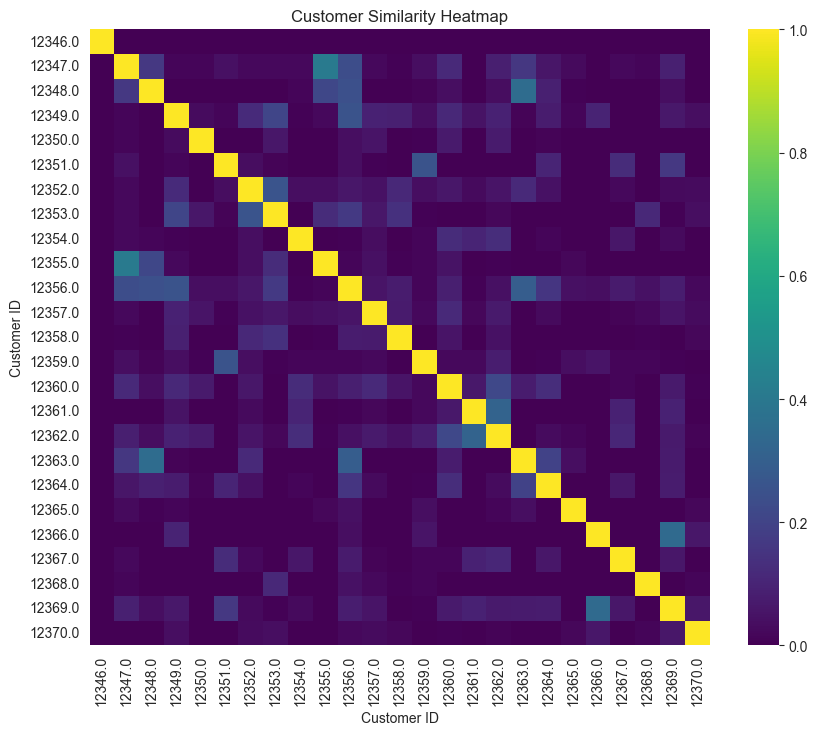

In [16]:
sample_similarity = customer_similarity_df.iloc[:25, :25]

plt.figure(figsize=(10,8))

sns.heatmap(
    sample_similarity,
    cmap="viridis"
)

plt.title("Customer Similarity Heatmap")

plt.show()

# ⭐ Popular Products

Popularity-based recommendations are useful for:

- New customers
- Cold-start situations
- Customers with insufficient purchase history

The most frequently purchased products are identified as default recommendations.

In [17]:
popular_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

popular_products.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

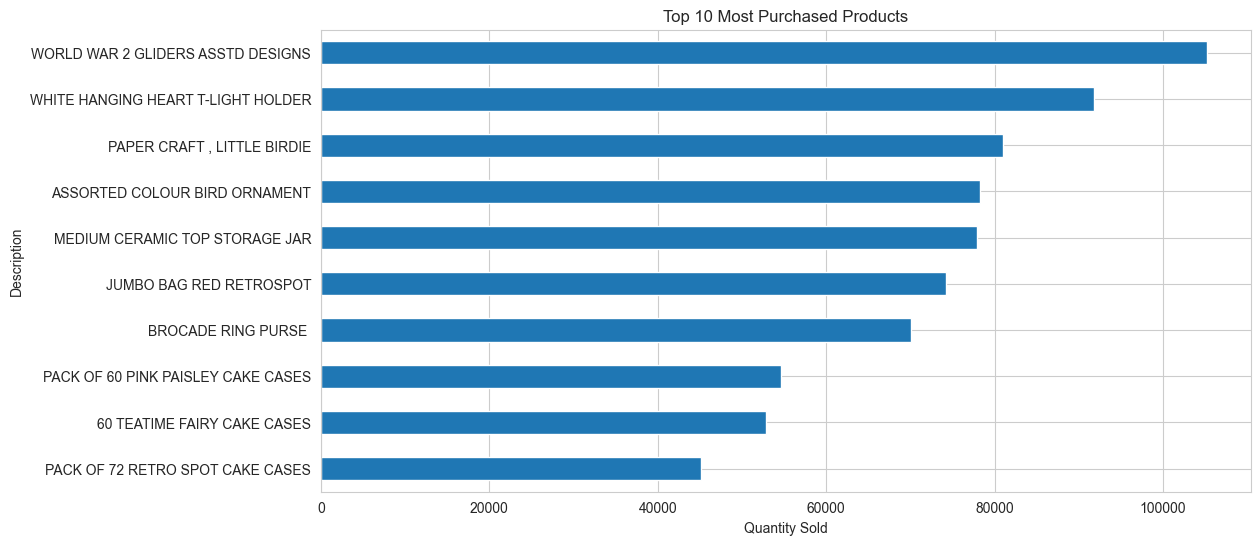

In [18]:
plt.figure(figsize=(12,6))

popular_products.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Most Purchased Products")

plt.xlabel("Quantity Sold")

plt.show()

#  Content-Based Recommendation

Content-Based Filtering recommends products that are similar in terms of their textual descriptions.

The product descriptions are converted into numerical vectors using TF-IDF (Term Frequency–Inverse Document Frequency). Cosine Similarity is then used to identify products with similar descriptions.

This method is especially useful when recommending products related to items that a customer has already purchased.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [20]:
product_df = (
    df[["Description"]]
    .drop_duplicates()
    .dropna()
)

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(
    product_df["Description"]
)

product_similarity = cosine_similarity(tfidf_matrix)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_df["Description"],
    columns=product_df["Description"]
)

In [21]:
def similar_products(product_name, top_n=5):

    if product_name not in product_similarity_df.index:
        return "Product not found."

    similar = (
        product_similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return similar

In [22]:
sample_product = product_df["Description"].iloc[0]

print(sample_product)

similar_products(sample_product)

15CM CHRISTMAS GLASS BALL 20 LIGHTS


Description
STRING OF 20 ROSE LIGHTS               0.410637
RED REINDEER STRING OF 20 LIGHTS       0.356271
DISCO BALL CHRISTMAS DECORATION        0.351623
SET OF 20 VINTAGE CHRISTMAS NAPKINS    0.348689
DRAWER KNOB VINTAGE GLASS BALL         0.330045
Name: 15CM CHRISTMAS GLASS BALL 20 LIGHTS, dtype: float64

#  Collaborative Filtering Recommendation Engine

A recommendation function is developed using customer similarity.

For a given customer:

1. Similar customers are identified.
2. Products purchased by similar customers are collected.
3. Already purchased products are excluded.
4. The remaining products are ranked and recommended.

In [23]:
def recommend_products(customer_id, top_n=5):

    if customer_id not in customer_product_matrix.index:
        return ["Customer not found"]

    similar_customers = (
        customer_similarity_df[customer_id]
        .sort_values(ascending=False)
        .iloc[1:11]
        .index
    )

    customer_products = set(
        customer_product_matrix.loc[customer_id]
        [
            customer_product_matrix.loc[customer_id] > 0
        ].index
    )

    recommendations = (
        customer_product_matrix
        .loc[similar_customers]
        .sum()
        .sort_values(ascending=False)
    )

    recommendations = recommendations[
        ~recommendations.index.isin(customer_products)
    ]

    return recommendations.head(top_n)

#  Hybrid Recommendation Strategy

Real-world recommendation systems rarely rely on a single algorithm.

To improve recommendation quality, a Hybrid Recommendation Engine is developed by combining:

- Popularity-based recommendations for new customers (Cold Start Problem)
- Collaborative Filtering using Customer Similarity
- Business Rules to remove already purchased products

This hybrid approach increases recommendation relevance while ensuring every customer receives useful product suggestions.

In [24]:
def hybrid_recommendation(customer_id, top_n=5):

    if customer_id not in customer_product_matrix.index:

        return popular_products.head(top_n)

    recommendations = recommend_products(customer_id, top_n)

    if len(recommendations) < top_n:

        remaining = top_n - len(recommendations)

        popular = popular_products[
            ~popular_products.index.isin(recommendations.index)
        ].head(remaining)

        recommendations = pd.concat([recommendations, popular])

    return recommendations.head(top_n)

#  Recommendation Examples

The recommendation engine is tested on multiple customers to verify that personalized product suggestions are generated successfully.

In [25]:
sample_customers = customer_product_matrix.index[:5]

for customer in sample_customers:

    print("=" * 60)

    print(f"Customer : {customer}")

    print(hybrid_recommendation(customer))

    print()

Customer : 12346.0
Description
PARTY BUNTING               362
SPOTTY BUNTING              300
WRAP ALPHABET DESIGN        250
CUPCAKE LACE PAPER SET 6    244
PAPER BUNTING WHITE LACE    240
dtype: int64

Customer : 12347.0
Description
DOUGHNUT LIP GLOSS                 100
PAPER CHAIN KIT RETRO SPOT          80
PAPER CHAIN KIT 50'S CHRISTMAS      78
PAPER CHAIN KIT EMPIRE              76
PACK OF 12 SPACEBOY TISSUES         72
dtype: int64

Customer : 12348.0
Description
PACK OF 12 PINK PAISLEY TISSUES     15176
PACK OF 60 DINOSAUR CAKE CASES       7608
PACK OF 72 RETROSPOT CAKE CASES      6216
PACK OF 72 RETRO SPOT CAKE CASES     4440
PACK OF 12 PINK SPOT TISSUES         3766
dtype: int64

Customer : 12349.0
Description
HEART OF WICKER SMALL                 182
ASSORTED CAKES FRIDGE MAGNETS         156
MINI CAKE STAND  HANGING STRAWBERY    140
HEART OF WICKER LARGE                 139
HEART FILIGREE DOVE  SMALL            138
dtype: int64

Customer : 12350.0
Description
WORLD WAR 2 GL

#  Cold Start Recommendation

New customers have no purchase history, making collaborative filtering impossible.

In such cases, the recommendation engine automatically returns the most popular products until sufficient customer interaction data becomes available.

In [26]:
print(
    hybrid_recommendation(
        999999999,
        top_n=5
    )
)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
Name: Quantity, dtype: int64


#  Creating Recommendation Dataset

Recommendations are generated for every customer and stored in a structured dataset.

This dataset can later be integrated into dashboards or deployed through the MeridianAI application.

In [27]:
recommendation_list = []

for customer in customer_product_matrix.index:

    recommendations = hybrid_recommendation(customer)

    for product in recommendations.index:

        recommendation_list.append(
            {
                "CustomerID": customer,
                "RecommendedProduct": product
            }
        )

recommendation_df = pd.DataFrame(recommendation_list)

recommendation_df.head()

,CustomerID,RecommendedProduct
0,12346.0,PARTY BUNTING
1,12346.0,SPOTTY BUNTING
2,12346.0,WRAP ALPHABET DESIGN
3,12346.0,CUPCAKE LACE PAPER SET 6
4,12346.0,PAPER BUNTING WHITE LACE


#  Recommendation Statistics

Summary statistics provide an overview of the recommendation dataset generated by the hybrid recommendation engine.

In [28]:
print("Customers :", recommendation_df["CustomerID"].nunique())

print("Recommendations :", len(recommendation_df))

print("Unique Products :", recommendation_df["RecommendedProduct"].nunique())

Customers : 5878
Recommendations : 29390
Unique Products : 1556


#  Recommendation Coverage

Recommendation Coverage measures the percentage of unique products that appear in the recommendation system.

Higher coverage indicates that the recommendation engine utilizes a larger portion of the product catalog.

In [29]:
coverage = (

    recommendation_df["RecommendedProduct"].nunique()

    /

    df["Description"].nunique()

) * 100

print(f"Recommendation Coverage : {coverage:.2f}%")

Recommendation Coverage : 29.45%


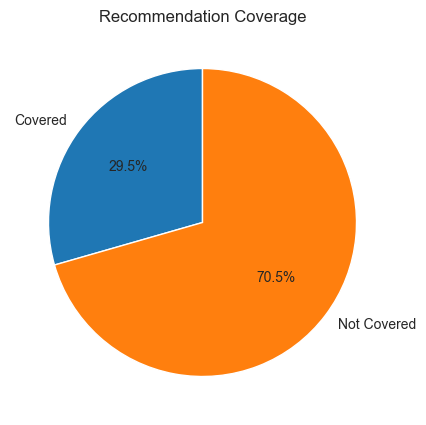

In [39]:
plt.figure(figsize=(8,5))

plt.pie(
    [
        coverage,
        100-coverage
    ],
    labels=[
        "Covered",
        "Not Covered"
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Recommendation Coverage")

plt.show()

#  Recommendation Diversity

Recommendation Diversity measures how varied the recommendations are across customers.

Higher diversity reduces recommendation repetition and improves customer experience.

In [30]:
diversity = (
    recommendation_df
    .groupby("CustomerID")["RecommendedProduct"]
    .nunique()
    .mean()
)

print(
    f"Average Unique Recommendations per Customer : {diversity:.2f}"
)

Average Unique Recommendations per Customer : 5.00


#  Most Frequently Recommended Products

Products appearing most often in recommendations represent highly relevant products across multiple customer groups.

In [31]:
top_products = (
    recommendation_df["RecommendedProduct"]
    .value_counts()
    .head(10)
)

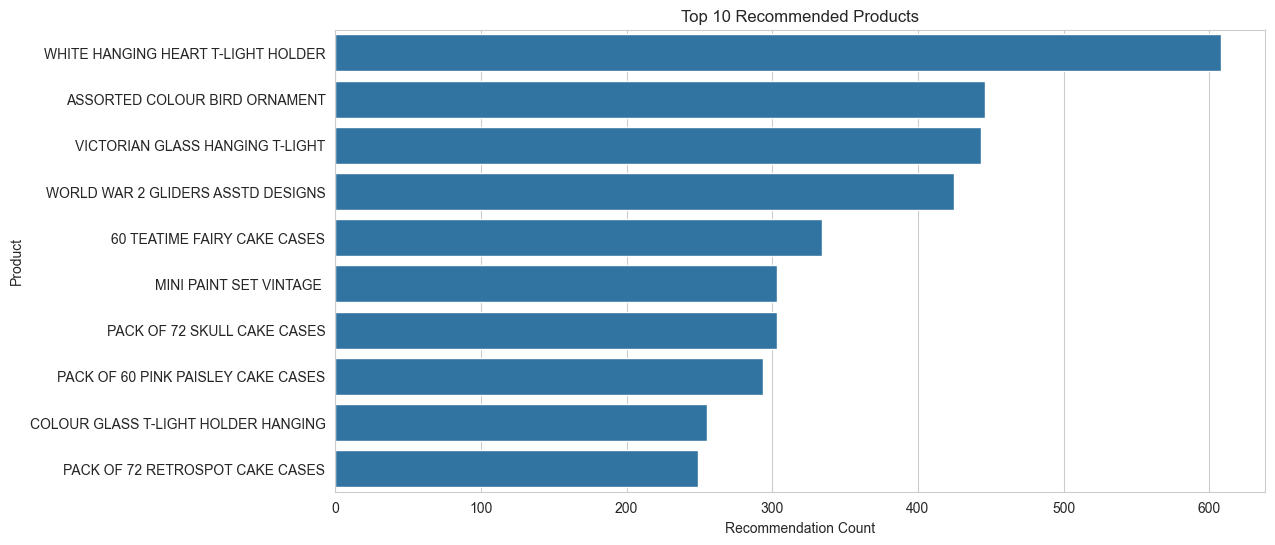

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Recommended Products")

plt.xlabel("Recommendation Count")

plt.ylabel("Product")

plt.show()

#  Recommendation Distribution

The following visualization shows how recommendations are distributed across customers.

In [33]:
recommendation_counts = (
    recommendation_df.groupby("CustomerID")
    .size()
)

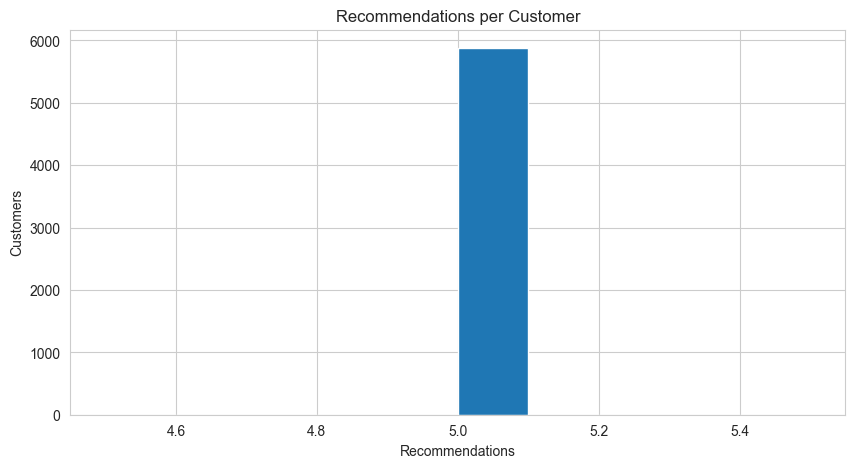

In [34]:
plt.figure(figsize=(10,5))

plt.hist(
    recommendation_counts,
    bins=10
)

plt.title("Recommendations per Customer")

plt.xlabel("Recommendations")

plt.ylabel("Customers")

plt.show()

#  Recommendation System Summary

The following table summarizes the overall performance and characteristics of the recommendation engine.

In [35]:
summary = pd.DataFrame({

    "Metric":[

        "Customers",

        "Products",

        "Recommendations",

        "Similarity Method",

        "Recommendation Strategy",

        "Cold Start Support",

        "Recommendation Coverage (%)",

        "Average Recommendation Diversity"

    ],

    "Value":[

        recommendation_df["CustomerID"].nunique(),

        df["Description"].nunique(),

        len(recommendation_df),

        "Cosine Similarity",

        "Hybrid",

        "Yes",

        round(coverage,2),

        round(diversity,2)

    ]

})

summary

,Metric,Value
0,Customers,5878
1,Products,5283
2,Recommendations,29390
3,Similarity Method,Cosine Similarity
4,Recommendation Strategy,Hybrid
5,Cold Start Support,Yes
6,Recommendation Coverage (%),29.45
7,Average Recommendation Diversity,5.0


#  Export Recommendation Dataset

The generated recommendations are exported for future deployment in the MeridianAI application.

In [36]:
recommendation_df.to_csv(
    "../data/processed/customer_recommendations.csv",
    index=False
)

#  Saving Recommendation Objects

The recommendation engine artifacts are saved so they can be reused directly by the deployment application without rebuilding the similarity matrix.

In [40]:
joblib.dump(
    customer_similarity_df,
    "../Models/customer_similarity.pkl"
)

joblib.dump(
    customer_product_matrix,
    "../Models/customer_product_matrix.pkl"
)

joblib.dump(
    popular_products,
    "../Models/popular_products.pkl"
)

joblib.dump(
    recommendation_df,
    "../Models/recommendation_dataset.pkl"
)

joblib.dump(
    product_similarity_df,
    "../Models/product_similarity.pkl"
)

['../Models/product_similarity.pkl']

#  Top Recommended Product Categories

The following visualization highlights the products that appear most frequently across all generated recommendations.

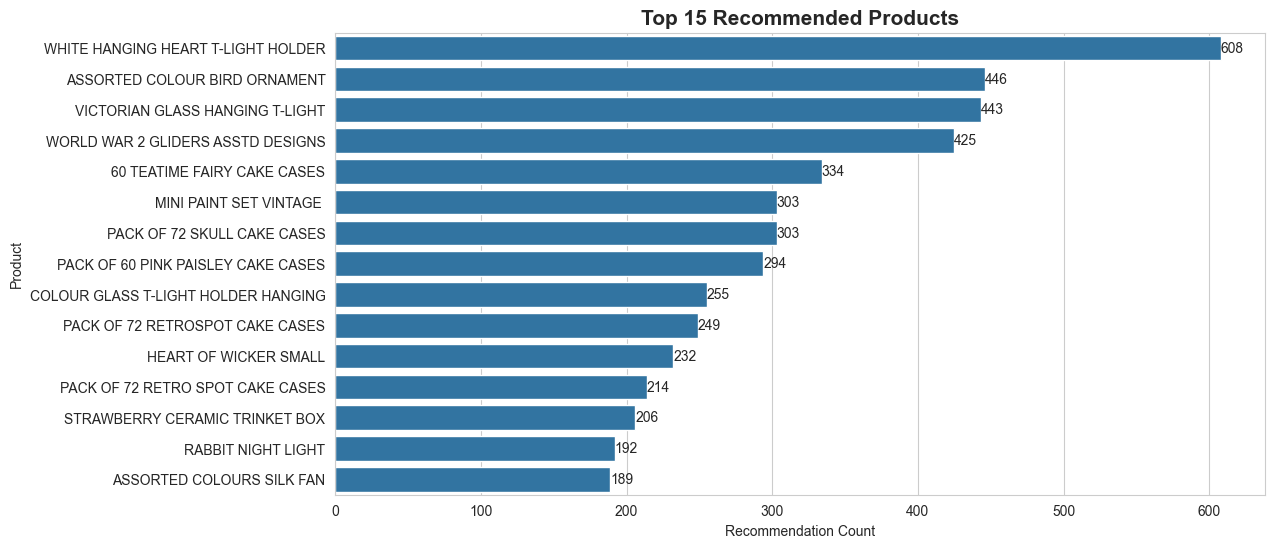

In [38]:
plt.figure(figsize=(12,6))

top_products = (
    recommendation_df["RecommendedProduct"]
    .value_counts()
    .head(15)
)

ax = sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title(
    "Top 15 Recommended Products",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Recommendation Count")
plt.ylabel("Product")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [44]:
print("RECOMMENDATION ENGINE SUMMARY")
print("=" * 30)

print(f"Customers Processed      : {recommendation_df['CustomerID'].nunique()}")
print(f"Unique Products          : {df['Description'].nunique()}")
print(f"Recommendations Created  : {len(recommendation_df)}")
print(f"Coverage                : {coverage:.2f}%")
print(f"Diversity               : {diversity:.2f}")
print(f"Sparsity                : {sparsity:.2%}")

RECOMMENDATION ENGINE SUMMARY
Customers Processed      : 5878
Unique Products          : 5283
Recommendations Created  : 29390
Coverage                : 29.45%
Diversity               : 5.00
Sparsity                : 98.41%


#  Business Conclusion

A Hybrid Recommendation Engine was successfully developed using collaborative filtering, customer similarity, and popularity-based recommendations.

The recommendation system analyzes historical purchasing behaviour to generate personalized product suggestions for each customer while addressing cold-start scenarios through popularity-based recommendations.

Business Value:

- Provides personalized shopping experiences.
- Increases cross-selling and upselling opportunities.
- Improves customer engagement and retention.
- Increases average order value.
- Supports targeted marketing campaigns.
- Produces reusable recommendation datasets and model artifacts for deployment within the MeridianAI platform.

The exported recommendation dataset and saved similarity matrices can be integrated directly into the Streamlit application to provide real-time product recommendations for customers.